End-to-End Sales Forecasting & Demand Intelligence System

Task 1 :  Data Loading, Merging & Deep Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
#Load Dataset
df = pd.read_csv("/content/train.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
print(df["Order Date"].sample(10))

6962    16/07/2017
8911    04/11/2018
9468    05/11/2018
2393    17/03/2017
1389    05/02/2017
8051    26/09/2015
3325    11/11/2015
7294    26/05/2016
6828    02/10/2017
6678    10/10/2015
Name: Order Date, dtype: object


In [8]:
#Parsing the order date & ship date  columns as proper datetime objects
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst= True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"],dayfirst=True)


In [9]:
print(df["Order Date"].head())
print(df["Ship Date"].head())

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[ns]
0   2017-11-11
1   2017-11-11
2   2017-06-16
3   2016-10-18
4   2016-10-18
Name: Ship Date, dtype: datetime64[ns]


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

#Extract time features

In [11]:

#Year
df["Year"] = df["Order Date"].dt.year
#Month
df["Month"] = df["Order Date"].dt.month
#Day
df["Day"] = df["Order Date"].dt.day
#month name
df["Month Name"] = df["Order Date"].dt.month_name()
#week number
df["Week"] = df["Order Date"].dt.isocalendar().week
# day of Week
df["Week"] = df["Order Date"].dt.isocalendar().week
#Quarter
df["Quarter"] = df["Order Date"].dt.quarter

In [12]:
#Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [13]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Day,Month Name,Week,Quarter,Season
7994,7995,US-2016-165743,2016-11-20,2016-11-23,Second Class,MM-18055,Michelle Moray,Consumer,United States,Aurora,...,Bookcases,Sauder Barrister Bookcases,145.764,2016,11,20,November,46,4,Autumn
3692,3693,US-2016-131359,2016-10-30,2016-11-02,Second Class,FA-14230,Frank Atkinson,Corporate,United States,Denver,...,Phones,OtterBox Commuter Series Case - iPhone 5 & 5s,87.960,2016,10,30,October,43,4,Autumn
8211,8212,CA-2017-116337,2017-11-07,2017-11-12,Standard Class,MC-17845,Michael Chen,Consumer,United States,Dallas,...,Furnishings,"Executive Impressions 14"" Contract Wall Clock ...",44.460,2017,11,7,November,45,4,Autumn
27,28,US-2016-150630,2016-09-17,2016-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.430,2016,9,17,September,37,3,Autumn
6505,6506,CA-2017-152331,2017-06-26,2017-06-30,Standard Class,LD-16855,Lela Donovan,Corporate,United States,Chicago,...,Art,Newell 311,5.304,2017,6,26,June,26,2,Summer


Missing values

In [14]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Duplicates

In [15]:
df.duplicated().sum()

np.int64(0)

Data Type Issues

In [16]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


Aggregate sales

In [17]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

In [18]:
daily_sales

,Order Date,Sales
0,2015-01-03,16.4480
1,2015-01-04,288.0600
2,2015-01-05,19.5360
3,2015-01-06,4407.1000
4,2015-01-07,87.1580
...,...,...
1225,2018-12-26,814.5940
1226,2018-12-27,177.6360
1227,2018-12-28,1657.3508
1228,2018-12-29,2915.5340


In [19]:
weekly_sales = (
    df.resample("W", on="Order Date")["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [20]:
monthly_sales = (
    df.resample("ME", on="Order Date")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Q1.Which product category generates the highest revenue?

Ans: Technology

In [21]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


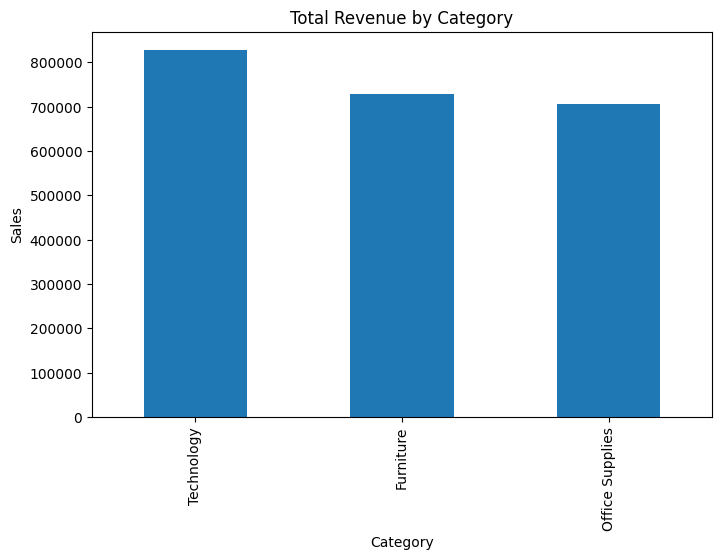

In [22]:
category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Revenue by Category")
plt.ylabel("Sales")
plt.show()

Q2.Which region has the most consistent sales growth?

Ans: East

In [23]:
region_year_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)
region_year_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


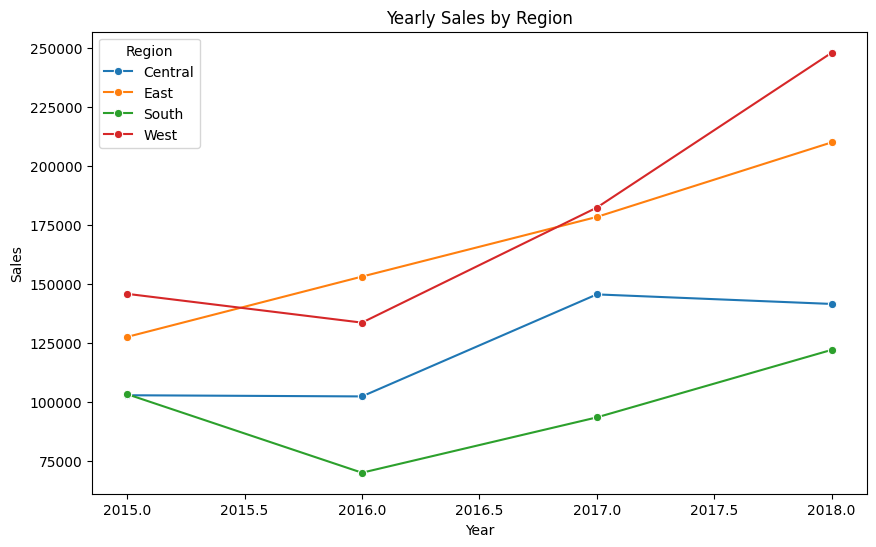

In [24]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales by Region")
plt.show()

Q3. Average Shipping Time

Ans: The overall average shipping time is 3.96 days. Across the four regions, the average shipping time ranges from 3.92 to 4.06 days, indicating only minor differences.

In [25]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days
df["Shipping Days"].mean()

np.float64(3.9611224489795918)

In [26]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
)

print(shipping_region)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


Q4. Are there months that consistently spike across all years?

Ans: March , September , November

In [27]:
monthly_pattern = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

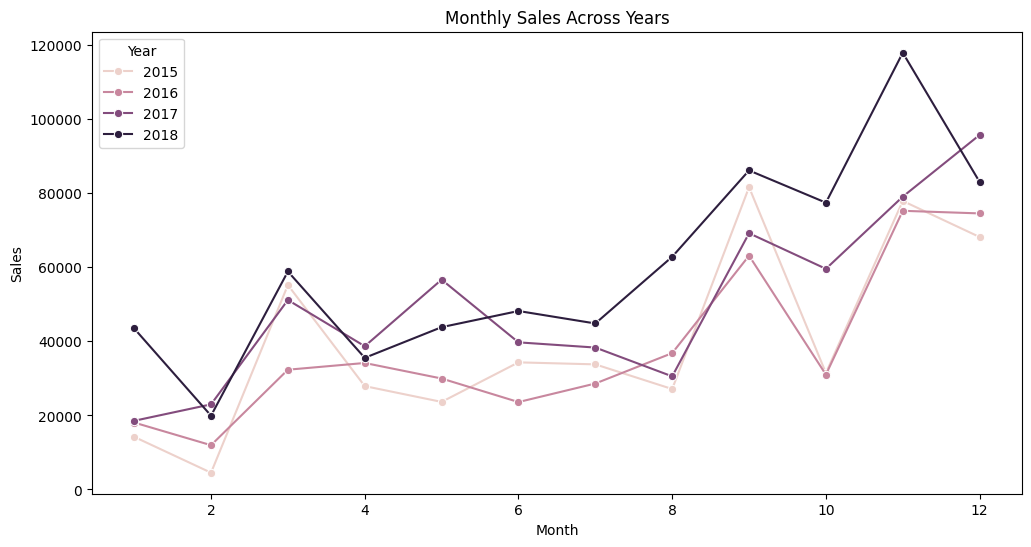

In [28]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_pattern,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Across Years")
plt.show()

Task 2 — Time Series Analysis & Decomposition

Monthly sales Trend

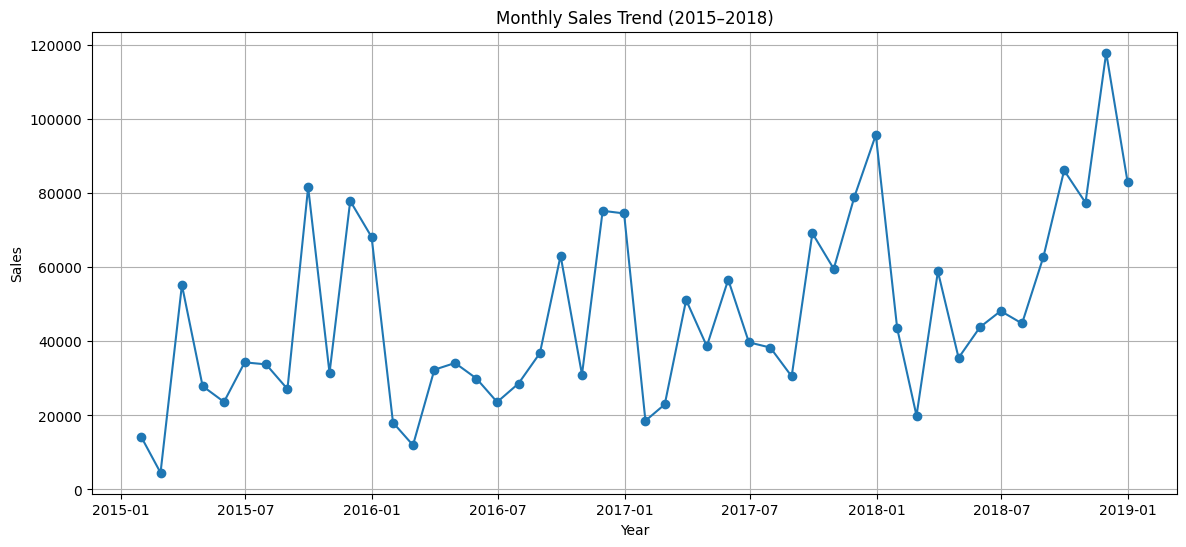

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend (2015–2018)")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

The overall sales trend is increasing over the four-year period, indicating steady business growth.

The decomposition indicates a clear seasonal pattern, with sales increasing during certain months each year and decreasing during others

Several sudden drops in monthly sales are observed following high-sales periods. These drops are likely caused by seasonal effects or the conclusion of promotional events

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [31]:
monthly_sales = monthly_sales.set_index("Order Date")

In [32]:
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

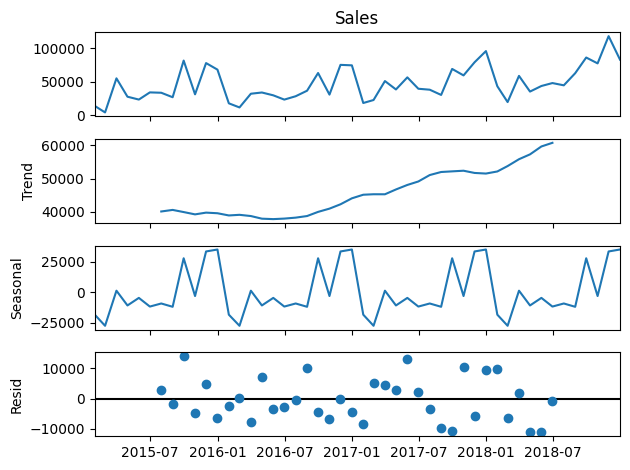

In [33]:
decomposition.plot()
plt.show()

The trend component shows that sales generally increased over the four-year period, indicating continuous business growth.

The seasonal component reveals a recurring yearly sales pattern, suggesting that customer demand is influenced by seasonal factors.

The seasonal component reveals a recurring yearly sales pattern, suggesting that customer demand is influenced by seasonal factors

Checking for stationarity using the Augmented Dickey-Fuller (ADF) Test

In [34]:
from statsmodels.tsa.stattools import adfuller

In [35]:
result = adfuller(monthly_sales["Sales"])

In [36]:
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


A time series is called stationary if its behavior does not change significantly over time. It fluctuates around a relatively constant level instead of showing a continuous upward or downward trend. Stable data is easier for forecasting models to analyze because the patterns remain consistent.

To check whether the monthly sales data is stationary, the Augmented Dickey-Fuller (ADF) Test was performed. The test produced an ADF statistic of -4.4161 and a p-value of 0.000278. Since the p-value is less than 0.05, the monthly sales series is considered stationary. This means the sales data is stable enough for time series forecasting models, so no differencing was required.

Task 3: Sales Forecasting using 3 Different Models

In [37]:
import itertools
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

In [38]:
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

In [39]:
print(train.shape)
print(test.shape)

(45, 1)
(3, 1)


In [40]:
order=(1,0,1)
seasonal_order=(1,0,1,12)

In [41]:
model = SARIMAX(
    train["Sales"],
    order=(1,0,1),
    seasonal_order=(1,0,1,12)
)

sarima_fit = model.fit()

In [42]:
forecast = sarima_fit.get_forecast(steps=3)

forecast_values = forecast.predicted_mean

confidence_intervals = forecast.conf_int()

In [43]:
mae = mean_absolute_error(test["Sales"], forecast_values)

rmse = np.sqrt(mean_squared_error(test["Sales"], forecast_values))

mape = np.mean(
    np.abs((test["Sales"]-forecast_values)/test["Sales"])
)*100

In [44]:
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 19730.37
RMSE : 24678.50
MAPE : 19.67%


In [45]:
final_model = SARIMAX(
    monthly_sales["Sales"],
    order=(1,0,1),
    seasonal_order=(1,0,1,12)
)

final_fit = final_model.fit()

future = final_fit.get_forecast(steps=3)

future.predicted_mean

,predicted_mean
2019-01-31,54982.918514
2019-02-28,42670.122643
2019-03-31,67741.347622


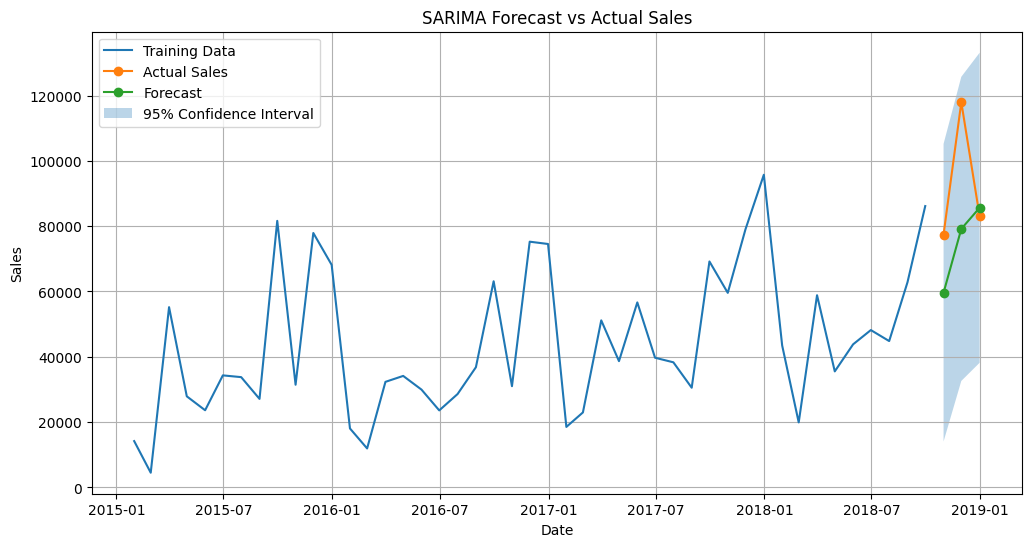

In [46]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train["Sales"], label="Training Data")

plt.plot(test.index, test["Sales"],
         marker="o",
         label="Actual Sales")

plt.plot(test.index,
         forecast_values,
         marker="o",
         label="Forecast")

plt.fill_between(
    test.index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.legend()

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

The ADF test confirmed that the monthly sales series was stationary (p-value < 0.05), so no differencing was required (d = 0). Since the data consists of monthly observations with yearly seasonality, the seasonal period was set to 12 (m = 12). A baseline SARIMA model with order (1,0,1) and seasonal order (1,0,1,12) was selected and evaluated on the test data.

In [47]:
!pip install prophet

In [48]:
from prophet import Prophet


In [49]:
prophet_data = monthly_sales.reset_index()

In [50]:
prophet_data = prophet_data.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

In [51]:
prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [52]:
train = prophet_data.iloc[:-3]
test = prophet_data.iloc[-3:]

In [53]:
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_model.fit(prophet_data)

In [54]:
future = final_model.make_future_dataframe(
    periods=3,
    freq="M"
)

In [55]:
future_forecast = final_model.predict(future)

In [56]:
future_forecast[["ds", "yhat"]].tail(3)

,ds,yhat
48,2019-01-31,42990.532205
49,2019-02-28,31248.159925
50,2019-03-31,81267.007775


AttributeError: 'Figure' object has no attribute 'title'

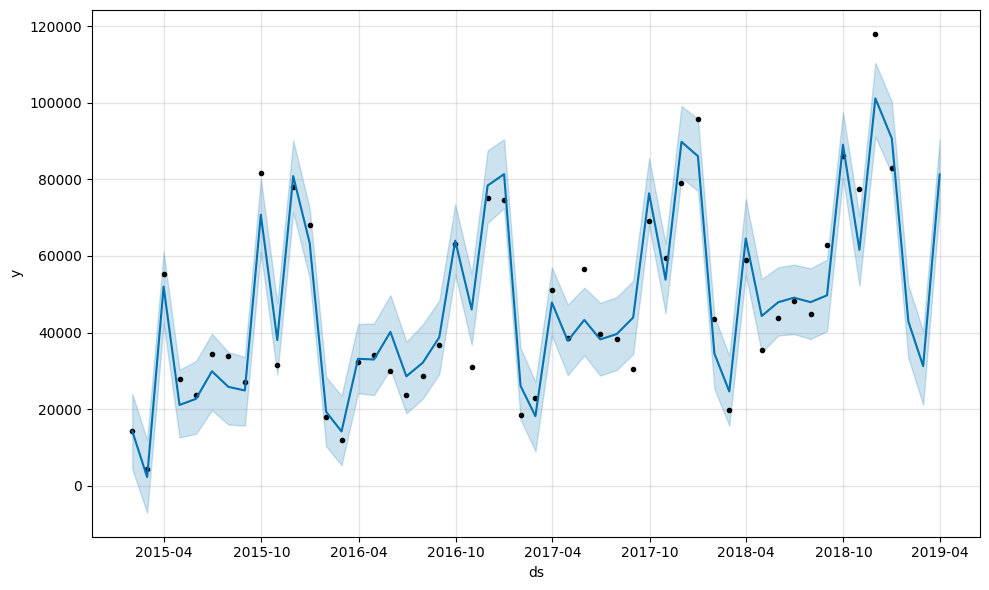

In [88]:
fig = final_model.plot(future_forecast)
ax = fig.gca()

ax.set_title("Prophet Sales Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.show()

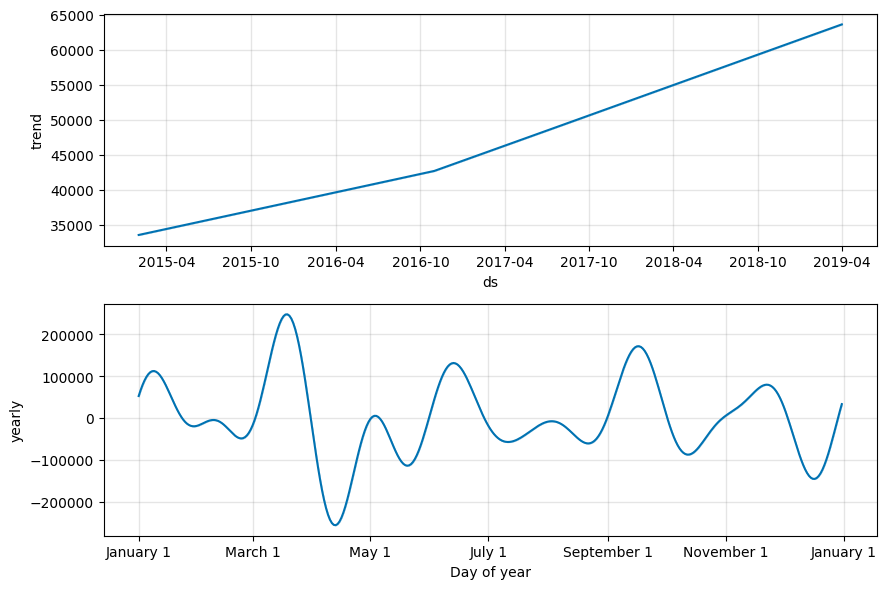

In [62]:
final_model.plot_components(future_forecast)

plt.show()

Trend: The Prophet model identifies a gradual upward trend in monthly sales over the four-year period, indicating overall business growth.

Yearly Seasonality: The yearly seasonality plot shows that sales fluctuate throughout the year. Some months consistently experience higher-than-average sales, while others are relatively weaker



In [89]:
forecast_test = future_forecast.tail(3)

In [90]:
predictions = future_forecast.tail(3)["yhat"].values

In [71]:
actual = test["y"].values

In [72]:
mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
mape = np.mean(
    np.abs((actual - predictions) / actual)
) * 100
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 40970.33
RMSE : 53868.95
MAPE : 40.04%


In [91]:
print(future_forecast[["ds", "yhat"]].tail(3))

           ds          yhat
48 2019-01-31  42990.532205
49 2019-02-28  31248.159925
50 2019-03-31  81267.007775


In [74]:
!pip install xgboost


In [75]:
from xgboost import XGBRegressor


In [76]:
xgb_data = monthly_sales.reset_index()

In [77]:
xgb_data.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [78]:
xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)

In [79]:
xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)

In [80]:
xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

In [81]:
xgb_data["Rolling_Mean"] = (
    xgb_data["Sales"]
    .rolling(3)
    .mean()
)

In [82]:
xgb_data["Month"] = (
    xgb_data["Order Date"]
    .dt.month
)

In [83]:
xgb_data["Quarter"] = (
    xgb_data["Order Date"]
    .dt.quarter
)

In [84]:
def season(month):

    if month in [12,1,2]:
        return 1      # Winter

    elif month in [3,4,5]:
        return 2      # Spring

    elif month in [6,7,8]:
        return 3      # Summer

    else:
        return 4      # Autumn

In [85]:
xgb_data["Season"] = (
    xgb_data["Month"]
    .apply(season)
)

In [86]:
xgb_data = xgb_data.dropna()

In [87]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean",
    "Month",
    "Quarter",
    "Season"
]

In [92]:
X = xgb_data[features]

In [93]:
y = xgb_data["Sales"]

In [94]:
X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

In [95]:
model = XGBRegressor(

    n_estimators=100,

    learning_rate=0.1,

    max_depth=3,

    random_state=42
)

In [96]:
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [97]:
last_sales = list(monthly_sales["Sales"].tail(3))

print(last_sales)

[77448.1312, 117938.155, 83030.3888]


In [101]:
future_predictions = []

for i in range(3):

    next_date = last_date + pd.DateOffset(months=i+1)

    month = next_date.month
    quarter = next_date.quarter

    if month in [12,1,2]:
        season = 1
    elif month in [3,4,5]:
        season = 2
    elif month in [6,7,8]:
        season = 3
    else:
        season = 4

    lag1 = last_sales[-1]
    lag2 = last_sales[-2]
    lag3 = last_sales[-3]

    rolling_mean = np.mean([lag1, lag2, lag3])

    features = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = model.predict(features)[0]

    future_predictions.append(prediction)

    last_sales.append(prediction)

In [102]:
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=3,
    freq="ME"
)

forecast_df = pd.DataFrame({
    "Month": future_dates,
    "Forecasted Sales": future_predictions
})

forecast_df

,Month,Forecasted Sales
0,2019-01-31,51037.703125
1,2019-02-28,30091.779297
2,2019-03-31,61376.886719


In [103]:
last_date = monthly_sales.index[-1]

In [104]:
predictions = model.predict(X_test)

In [105]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

mape = np.mean(
    np.abs(
        (y_test-predictions)/y_test
    )
)*100

In [106]:
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


MAE : 13915.32
RMSE: 18893.85
MAPE: 13.29%


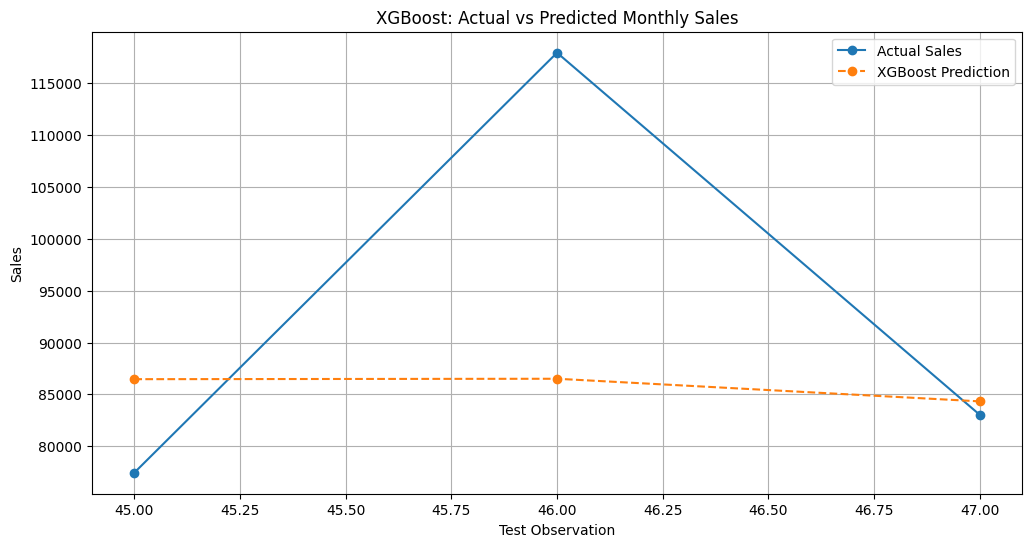

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    predictions,
    marker="o",
    linestyle="--",
    label="XGBoost Prediction"
)

plt.title("XGBoost: Actual vs Predicted Monthly Sales")

plt.xlabel("Test Observation")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

The XGBoost model captures the overall sales pattern reasonably well. Although it underestimates the sudden increase in sales during one of the test months, it predicts the remaining months closely.

In [109]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [19730.37, 20250.79, 13915.32],
    "RMSE": [24678.50, 22318.41, 18893.85],
    "MAPE (%)": [19.67, 21.86, 13.29],
    "Forecast Month 1": [
        54982.92,
        future_forecast["yhat"].iloc[-3],
        51037.70
    ],
    "Forecast Month 2": [
        42670.12,
        future_forecast["yhat"].iloc[-2],
        30091.78
    ],
    "Forecast Month 3": [
        67741.35,
        future_forecast["yhat"].iloc[-1],
        61376.89
    ]
})

comparison

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19730.37,24678.50,19.67,54982.920000,42670.120000,67741.350000
1,Prophet,20250.79,22318.41,21.86,42990.532205,31248.159925,81267.007775
2,XGBoost,13915.32,18893.85,13.29,51037.700000,30091.780000,61376.890000


Three forecasting models:SARIMA, Prophet, and XGBoost,were developed and evaluated using MAE, RMSE, and MAPE. XGBoost achieved the lowest error across all three evaluation metrics (MAE = 13,915.32, RMSE = 18,893.85, and MAPE = 13.29%), indicating the highest forecasting accuracy.

Although SARIMA and Prophet were able to capture the trend and seasonality of the sales data, XGBoost provided more accurate predictions by leveraging lag-based and time-related features. Therefore, based on quantitative performance rather than preference, XGBoost is recommended for production use on this dataset

Task 4 : Product Category & Region Level Forecasting

In [110]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

def forecast_xgboost(segment_df):

    # Aggregate monthly sales
    monthly = (
        segment_df
        .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

    # Feature Engineering
    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)

    monthly["Rolling_Mean"] = monthly["Sales"].rolling(3).mean()

    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter

    def season(month):
        if month in [12,1,2]:
            return 1
        elif month in [3,4,5]:
            return 2
        elif month in [6,7,8]:
            return 3
        else:
            return 4

    monthly["Season"] = monthly["Month"].apply(season)

    monthly = monthly.dropna()

    features = [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean",
        "Month",
        "Quarter",
        "Season"
    ]

    X = monthly[features]
    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    last_sales = list(monthly["Sales"].tail(3))
    last_date = monthly["Order Date"].iloc[-1]

    predictions = []

    for i in range(3):

        next_date = last_date + pd.DateOffset(months=i+1)

        month = next_date.month
        quarter = next_date.quarter

        if month in [12,1,2]:
            season_value = 1
        elif month in [3,4,5]:
            season_value = 2
        elif month in [6,7,8]:
            season_value = 3
        else:
            season_value = 4

        lag1 = last_sales[-1]
        lag2 = last_sales[-2]
        lag3 = last_sales[-3]

        rolling = np.mean([lag1, lag2, lag3])

        future = pd.DataFrame({
            "Lag_1":[lag1],
            "Lag_2":[lag2],
            "Lag_3":[lag3],
            "Rolling_Mean":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season_value]
        })

        pred = model.predict(future)[0]

        predictions.append(pred)

        last_sales.append(pred)

    future_dates = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=3,
        freq="ME"
    )

    return pd.DataFrame({
        "Date": future_dates,
        "Forecast": predictions
    })

In [111]:
#Furniture
furniture_forecast = forecast_xgboost(
    df[df["Category"]=="Furniture"]
)

In [112]:
#Technology
technology_forecast = forecast_xgboost(
    df[df["Category"]=="Technology"]
)

In [113]:
#office Supplies
office_forecast = forecast_xgboost(
    df[df["Category"]=="Office Supplies"]
)

In [114]:
#west
west_forecast = forecast_xgboost(
    df[df["Region"]=="West"]
)

In [115]:
#East
east_forecast = forecast_xgboost(
    df[df["Region"]=="East"]
)

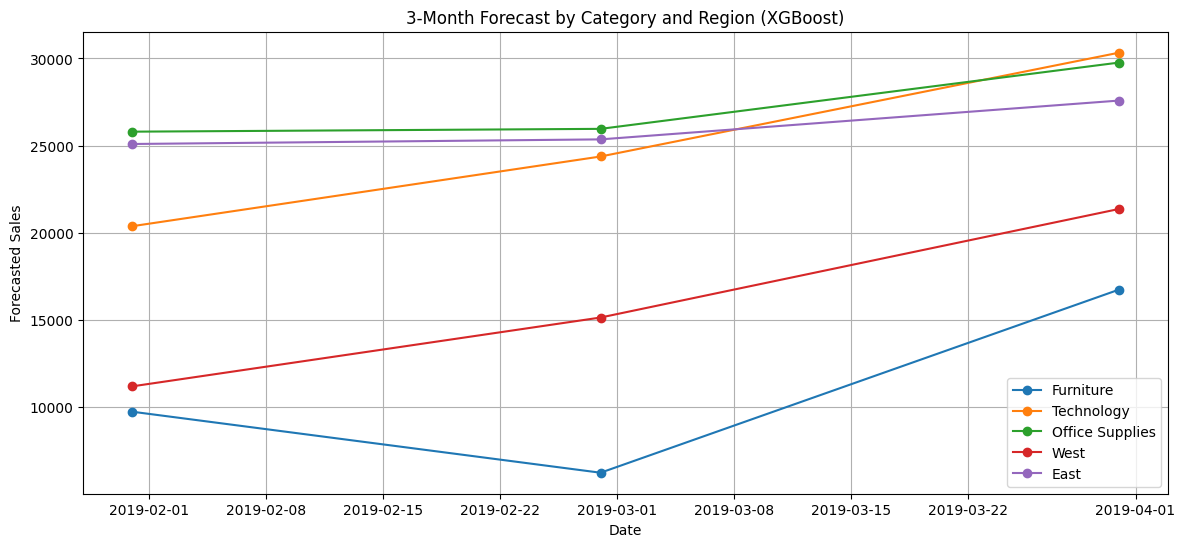

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    furniture_forecast["Date"],
    furniture_forecast["Forecast"],
    marker="o",
    label="Furniture"
)

plt.plot(
    technology_forecast["Date"],
    technology_forecast["Forecast"],
    marker="o",
    label="Technology"
)

plt.plot(
    office_forecast["Date"],
    office_forecast["Forecast"],
    marker="o",
    label="Office Supplies"
)

plt.plot(
    west_forecast["Date"],
    west_forecast["Forecast"],
    marker="o",
    label="West"
)

plt.plot(
    east_forecast["Date"],
    east_forecast["Forecast"],
    marker="o",
    label="East"
)

plt.title("3-Month Forecast by Category and Region (XGBoost)")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.legend()
plt.grid(True)

plt.show()

In [117]:
print("Furniture")
print(furniture_forecast)

print("\nTechnology")
print(technology_forecast)

print("\nOffice Supplies")
print(office_forecast)

print("\nWest")
print(west_forecast)

print("\nEast")
print(east_forecast)

Furniture
        Date      Forecast
0 2019-01-31   9716.002930
1 2019-02-28   6214.686523
2 2019-03-31  16723.810547

Technology
        Date      Forecast
0 2019-01-31  20370.966797
1 2019-02-28  24370.316406
2 2019-03-31  30328.619141

Office Supplies
        Date      Forecast
0 2019-01-31  25796.031250
1 2019-02-28  25957.259766
2 2019-03-31  29761.830078

West
        Date      Forecast
0 2019-01-31  11175.511719
1 2019-02-28  15125.338867
2 2019-03-31  21355.615234

East
        Date      Forecast
0 2019-01-31  25088.458984
1 2019-02-28  25353.447266
2 2019-03-31  27580.826172


Technology shows the strongest growth trend because sales increase consistently every month and by the largest amount (from ~20.4K to ~30.3K).

Office Supplies also grows, but at a slower rate.

Furniture is more volatile since sales decrease in February before increasing in March.

For regional forecasts, the East region is projected to have the highest sales throughout the forecast period, indicating sustained market strength. The West region also demonstrates positive growth but remains below the East region in terms of forecasted sales.

Task 5 — Anomaly Detection in Sales Data

In [118]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [119]:
from sklearn.ensemble import IsolationForest

In [120]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [121]:
weekly_sales["Anomaly"] = weekly_sales["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

In [122]:
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == "Anomaly"
]

anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,Anomaly
5,2015-02-08,968.534,Anomaly
7,2015-02-22,224.912,Anomaly
11,2015-03-22,37703.665,Anomaly
28,2015-07-19,1387.686,Anomaly
36,2015-09-13,29959.137,Anomaly
55,2016-01-24,358.522,Anomaly
154,2017-12-17,25449.800,Anomaly
200,2018-11-04,29017.467,Anomaly
202,2018-11-18,30572.447,Anomaly


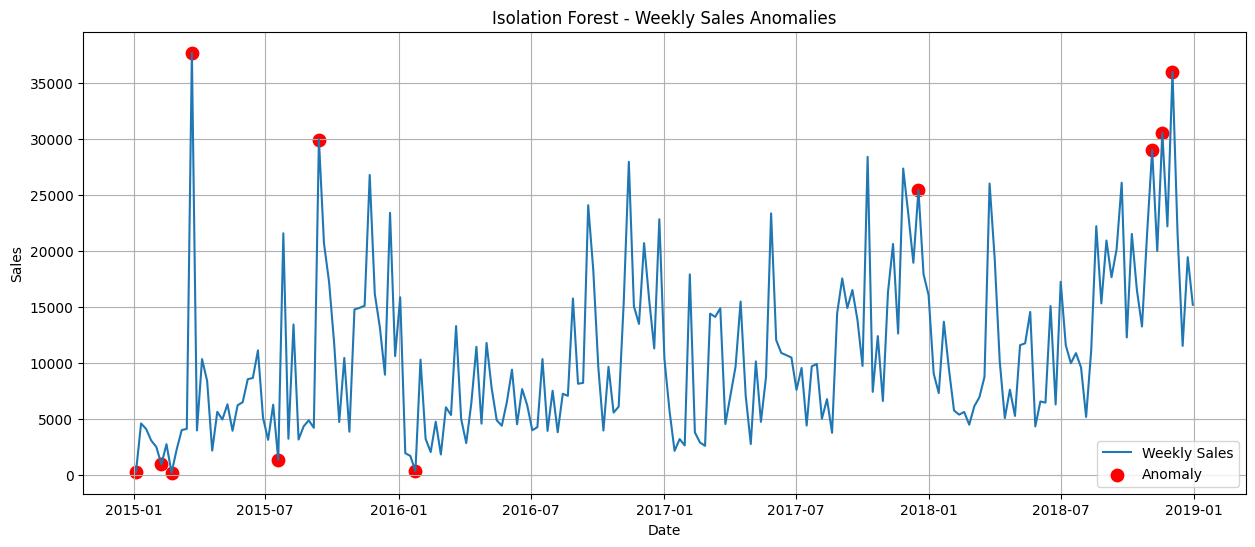

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

Isolation Forest identified unusual weeks by isolating observations that differ significantly from the general sales pattern. Both unusually high and unusually low sales weeks were detected as anomalies.

In [124]:
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean()
)

weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .std()
)

In [125]:
weekly_sales["Z_Score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling Mean"])
    /
    weekly_sales["Rolling Std"]
)

In [126]:
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"]
    .abs()
    > 2
)

In [127]:
z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

z_anomalies

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Z_Score,Z_Anomaly


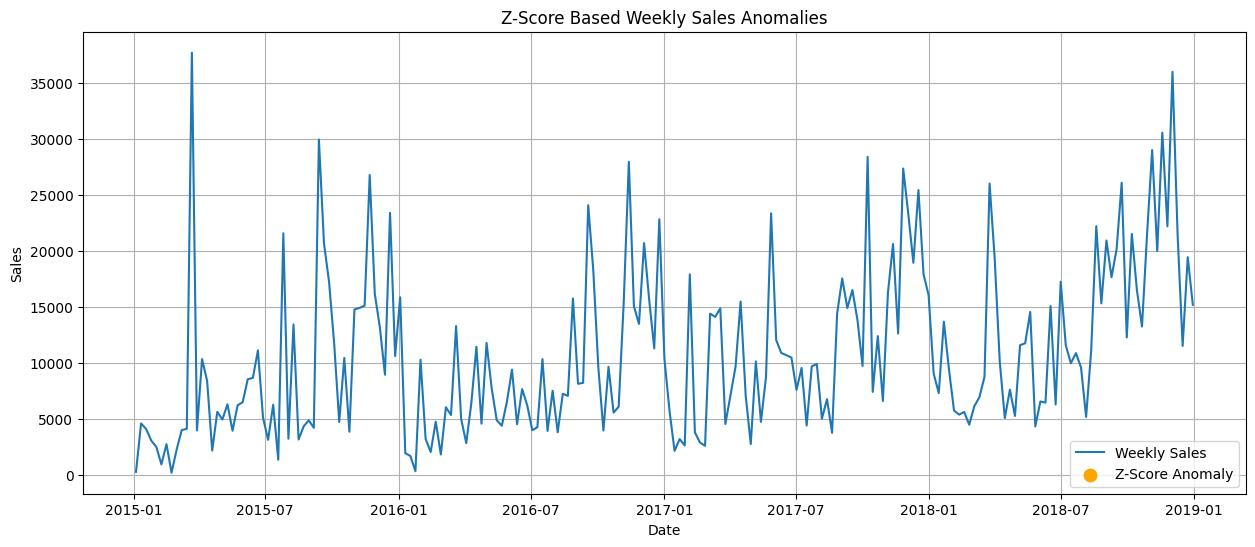

In [128]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [129]:
comparison = weekly_sales[
    ["Order Date", "Sales", "Anomaly", "Z_Anomaly"]
]

comparison.head()

,Order Date,Sales,Anomaly,Z_Anomaly
0,2015-01-04,304.508,Anomaly,False
1,2015-01-11,4619.108,Normal,False
2,2015-01-18,4130.533,Normal,False
3,2015-01-25,3092.544,Normal,False
4,2015-02-01,2527.914,Normal,False


The Isolation Forest model identified several anomalous weeks, while the Z-Score method did not detect any. This indicates that Isolation Forest is more sensitive to unusual patterns in the data because it uses a machine learning approach that isolates observations based on the overall data distribution. In contrast, the Z-Score method relies on a fixed statistical threshold, which may not identify anomalies when the rolling standard deviation is relatively large.

Task 6 : Product Demand Segmentation using clustering

In [130]:
monthly_subcategory = (
    df.groupby(
        ["Sub-Category", pd.Grouper(key="Order Date", freq="ME")]
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_subcategory.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [131]:
features = []

for subcategory in monthly_subcategory["Sub-Category"].unique():

    temp = monthly_subcategory[
        monthly_subcategory["Sub-Category"] == subcategory
    ].sort_values("Order Date")

    total_sales = temp["Sales"].sum()

    avg_order_value = (
        df[df["Sub-Category"] == subcategory]["Sales"].mean()
    )

    volatility = temp["Sales"].std()

    yearly = (
        temp.set_index("Order Date")
        .resample("YE")["Sales"]
        .sum()
    )

    if len(yearly) > 1:
        growth = (
            (yearly.iloc[-1] - yearly.iloc[0])
            /
            yearly.iloc[0]
        ) * 100
    else:
        growth = 0

    features.append([
        subcategory,
        total_sales,
        growth,
        volatility,
        avg_order_value
    ])

In [132]:
cluster_df = pd.DataFrame(
    features,
    columns=[
        "Sub-Category",
        "Total Sales",
        "Growth Rate",
        "Volatility",
        "Average Order Value"
    ]
)

cluster_df

,Sub-Category,Total Sales,Growth Rate,Volatility,Average Order Value
0,Accessories,164186.7000,145.055961,2579.994809,217.178175
1,Appliances,104618.4030,165.242912,1821.621539,227.926804
2,Art,26705.4100,49.649531,330.488343,34.019631
3,Binders,200028.7850,65.778638,3848.223648,134.067550
4,Bookcases,113813.1987,49.846598,2220.405080,503.598224
5,Chairs,322822.7310,20.954677,4407.232960,531.833165
6,Copiers,146248.0940,479.729510,5500.774391,2215.880212
7,Envelopes,16128.0460,-12.121345,228.218688,65.032444
8,Fasteners,3001.9600,30.468364,48.742229,14.027850
9,Furnishings,89212.0180,106.824969,1360.017867,95.823865


In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(
    cluster_df.drop("Sub-Category", axis=1)
)

In [134]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertia.append(model.inertia_)

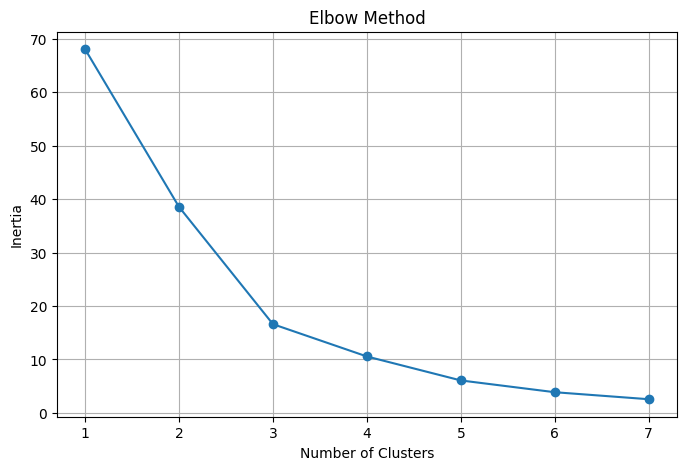

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1,8),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [136]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(X)

In [137]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(X)

cluster_df["PC1"] = components[:,0]
cluster_df["PC2"] = components[:,1]

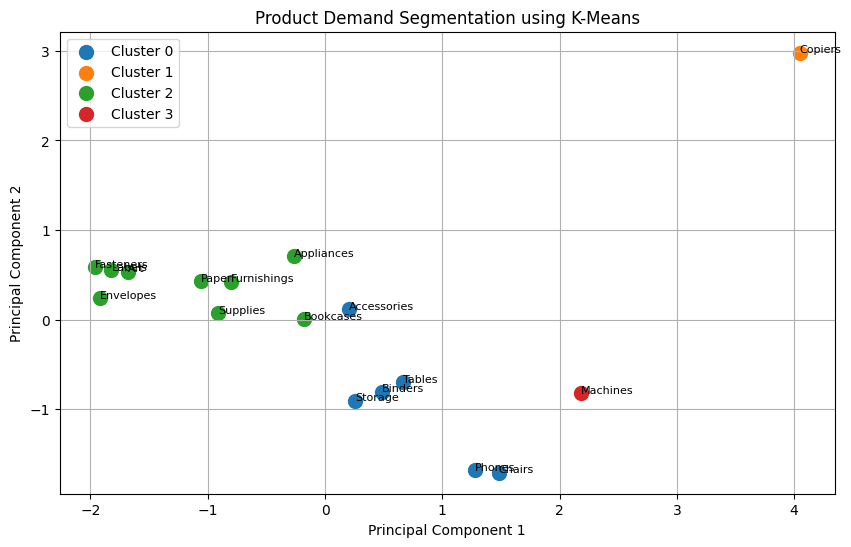

In [138]:
plt.figure(figsize=(10,6))

for cluster in sorted(cluster_df["Cluster"].unique()):

    temp = cluster_df[
        cluster_df["Cluster"] == cluster
    ]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=100,
        label=f"Cluster {cluster}"
    )

    for _, row in temp.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            row["Sub-Category"],
            fontsize=8
        )

plt.title("Product Demand Segmentation using K-Means")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()

In [139]:
cluster_df.sort_values("Cluster")

,Sub-Category,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PC1,PC2
0,Accessories,164186.7000,145.055961,2579.994809,217.178175,0,0.200367,0.116729
3,Binders,200028.7850,65.778638,3848.223648,134.067550,0,0.484161,-0.805597
5,Chairs,322822.7310,20.954677,4407.232960,531.833165,0,1.479554,-1.711393
14,Storage,219343.3920,38.366108,2822.084310,263.633885,0,0.254384,-0.905577
13,Phones,327782.4480,35.557607,4052.718221,374.180877,0,1.274893,-1.682174
16,Tables,202810.6280,33.078016,3224.082504,645.893720,0,0.663161,-0.700053
6,Copiers,146248.0940,479.729510,5500.774391,2215.880212,1,4.046026,2.979941
2,Art,26705.4100,49.649531,330.488343,34.019631,2,-1.676784,0.535820
7,Envelopes,16128.0460,-12.121345,228.218688,65.032444,2,-1.920711,0.234844
4,Bookcases,113813.1987,49.846598,2220.405080,503.598224,2,-0.176589,0.003166


In [140]:
cluster_df.groupby("Cluster").mean(numeric_only=True)

,Total Sales,Growth Rate,Volatility,Average Order Value,PC1,PC2
Cluster,,,,,,
0,239495.780667,56.465168,3489.056075,361.131228,0.726087,-0.948011
1,146248.094000,479.729510,5500.774391,2215.880212,4.046026,2.979941
2,54341.708189,58.795823,1031.431565,142.746758,-1.175792,0.392146
3,189238.631000,-29.793120,5603.554747,1645.553313,2.179582,-0.821189


Product Demand Segmentation

K-Means clustering grouped the product sub-categories into four distinct demand segments based on total sales, year-over-year growth, sales volatility, and average order value.

Cluster 0 High Volume, Stable Demand

This cluster contains high-performing products such as Chairs, Phones, Tables, Storage, Accessories, and Binders. These products generate consistently high sales and should receive priority in inventory planning to prevent stockouts.

Cluster 1 High Value, Rapid Growth

This cluster contains only Copiers. Although sales are more volatile, Copiers have the highest average order value and an exceptionally high growth rate. Inventory should be managed carefully by balancing availability with the high carrying cost.

Cluster 2  Low Volume, Stable Demand

This cluster consists of products with relatively lower sales volumes and moderate growth. These items should be stocked conservatively and replenished according to demand to avoid unnecessary inventory costs.

Cluster 3  Declining Demand

Machines form a separate cluster because they exhibit declining sales growth and high variability. Inventory for these products should be minimized, and sales trends should be monitored to determine whether promotional actions or product rationalization are required